Starting training...
Episode 100000/10000000 - Average Reward per Bet: -10.54%
Episode 200000/10000000 - Average Reward per Bet: -8.67%
Episode 300000/10000000 - Average Reward per Bet: -7.80%
Episode 400000/10000000 - Average Reward per Bet: -7.15%
Episode 500000/10000000 - Average Reward per Bet: -6.85%
Episode 600000/10000000 - Average Reward per Bet: -6.67%
Episode 700000/10000000 - Average Reward per Bet: -6.44%
Episode 800000/10000000 - Average Reward per Bet: -6.23%
Episode 900000/10000000 - Average Reward per Bet: -6.12%
Episode 1000000/10000000 - Average Reward per Bet: -6.01%
Episode 1100000/10000000 - Average Reward per Bet: -5.90%
Episode 1200000/10000000 - Average Reward per Bet: -5.81%
Episode 1300000/10000000 - Average Reward per Bet: -5.75%
Episode 1400000/10000000 - Average Reward per Bet: -5.71%
Episode 1500000/10000000 - Average Reward per Bet: -5.64%
Episode 1600000/10000000 - Average Reward per Bet: -5.59%
Episode 1700000/10000000 - Average Reward per Bet: -5.59%
E

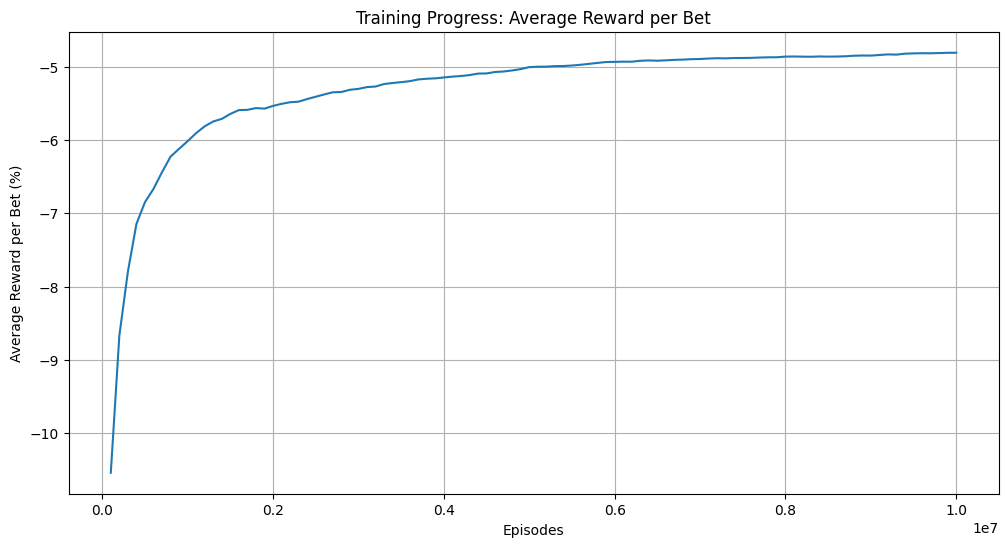

Model saved as 'blackjack_model.pkl'.
Model loaded for evaluation.

Evaluation over 100000 episodes:
Win %: 41.12%
Loss %: 50.84%
Draw %: 8.04%
Average Reward per Bet (%): -0.45%


In [4]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
import random
import pickle

# -------------------------
# 1. CUSTOM BLACKJACK ENVIRONMENT USING GYMNASIUM
# -------------------------
class BlackjackEnv(gym.Env):
    """
    A simplified blackjack environment supporting:
      - HIT (0): take a new card,
      - STK (1): stick (stand),
      - DBL (2): double down (double the bet, draw one card, then stand),
      - SUR (3): surrender (forfeit half the bet).
    
    Implements natural blackjack:
      - If the player's initial hand is an Ace and a 10‐value card (blackjack)
        and the dealer does not have blackjack, reward is +1.5 (3:2 payout).
        
    Simplifications:
      - Infinite deck.
      - Dealer stands on 17.
      - No insurance.
      - Only on the first move are DBL and SUR allowed; afterwards only HIT and STK.
    """
    
    def __init__(self, natural=True):
        super(BlackjackEnv, self).__init__()
        self.action_space = spaces.Discrete(4)  # actions: 0=HIT, 1=STK, 2=DBL, 3=SUR
        # Observation: (player sum, dealer's first card, usable ace flag, first_move flag)
        self.observation_space = spaces.Tuple((
            spaces.Discrete(32),   # player sum (safety bound up to 31)
            spaces.Discrete(11),   # dealer card: 1..10 (Ace as 1)
            spaces.Discrete(2),    # usable ace flag: 0 or 1
            spaces.Discrete(2)     # first_move flag: 0 (False) or 1 (True)
        ))
        self.natural = natural
        self.seed()
        self.reset()
        
    def seed(self, seed=None):
        random.seed(seed)
        np.random.seed(seed)
        
    def draw_card(self):
        cards = [1,2,3,4,5,6,7,8,9,10,10,10,10]
        return random.choice(cards)
    
    def draw_hand(self):
        return [self.draw_card(), self.draw_card()]
    
    def usable_ace(self, hand):
        return 1 in hand and sum(hand) + 10 <= 21
    
    def sum_hand(self, hand):
        s = sum(hand)
        if self.usable_ace(hand):
            return s + 10
        return s
    
    def is_bust(self, hand):
        return self.sum_hand(hand) > 21
    
    def is_natural(self, hand):
        return sorted(hand) == [1, 10]
    
    def _get_obs(self):
        return (self.sum_hand(self.player), self.dealer[0], int(self.usable_ace(self.player)), int(self.first_move))
    
    def _dealer_play(self):
        # Dealer draws until reaching at least 17.
        while self.sum_hand(self.dealer) < 17:
            self.dealer.append(self.draw_card())
        player_sum = self.sum_hand(self.player) if not self.is_bust(self.player) else 0
        dealer_sum = self.sum_hand(self.dealer) if not self.is_bust(self.dealer) else 0
        
        # Check natural blackjack payout
        if self.natural and len(self.player) == 2 and self.is_natural(self.player):
            if len(self.dealer) == 2 and self.is_natural(self.dealer):
                return 0  # push
            else:
                return 1.5 * self.current_bet
        
        if dealer_sum > 21:  # dealer busts
            return self.current_bet
        if player_sum > dealer_sum:
            return self.current_bet
        elif player_sum == dealer_sum:
            return 0
        else:
            return -self.current_bet
        
    def step(self, action):
        """
        Executes an action:
          0: HIT – draw a card,
          1: STK – stick and let dealer play,
          2: DBL – double down (double bet, draw one card, then stand),
          3: SUR – surrender (lose half the bet).
        If DBL or SUR are taken after the first move, they are forced to act as HIT.
        Returns: observation, reward, terminated, truncated, info.
        """
        if self.done:
            return self._get_obs(), 0, True, False, {}
        
        if action not in [0, 1, 2, 3]:
            raise ValueError("Invalid action")
        
        # Enforce legal actions: only allow DBL and SUR on the first move.
        if not self.first_move and action in [2, 3]:
            action = 0
        
        self.first_move = False  # subsequent moves are no longer the first
        
        if action == 0:  # HIT
            card = self.draw_card()
            self.player.append(card)
            if self.is_bust(self.player):
                reward = -self.current_bet
                self.done = True
            else:
                reward = 0
        elif action == 1:  # STK (stick)
            reward = self._dealer_play()
            self.done = True
        elif action == 2:  # DBL (double)
            self.current_bet *= 2
            card = self.draw_card()
            self.player.append(card)
            if self.is_bust(self.player):
                reward = -self.current_bet
            else:
                reward = self._dealer_play()
            self.done = True
        elif action == 3:  # SUR (surrender)
            reward = -0.5 * self.current_bet
            self.done = True
        
        return self._get_obs(), reward, self.done, False, {}
    
    def reset(self, *, seed=None, options=None):
        self.done = False
        self.current_bet = 1
        self.player = self.draw_hand()
        self.dealer = self.draw_hand()
        self.first_move = True
        
        # Immediately check for natural blackjack.
        if self.natural and self.is_natural(self.player):
            if self.is_natural(self.dealer):
                self.done = True
                self.last_reward = 0
            else:
                self.done = True
                self.last_reward = 1.5 * self.current_bet
        return self._get_obs(), {}

# -------------------------
# 2. TRAINING USING MONTE CARLO METHOD
# -------------------------
env = BlackjackEnv(natural=True)

# Dictionaries for Q-values and returns
Q = {}              # (state, action) -> value
returns_sum = {}    # cumulative returns for each (state, action)
returns_count = {}  # counts for each (state, action)
policy = {}         # state -> best action

# Hyperparameters
N_EPISODES = 10_000_000  # Total training episodes
epsilon = 0.1            # Epsilon for epsilon–soft policy

# Tracking training progress
plot_x = []
avg_reward_per_bet = []
cumulative_reward = 0
total_bet_amount = 0

def get_allowed_actions(state):
    # The state is a tuple: (player_sum, dealer_card, usable_ace, first_move)
    if state[3] == 1:
        return [0, 1, 2, 3]
    else:
        return [0, 1]

def get_action(state):
    allowed = get_allowed_actions(state)
    # If a greedy action exists for this state and is allowed, choose it with probability 1 - epsilon.
    if state in policy and policy[state] in allowed and np.random.rand() > epsilon:
        return policy[state]
    # Otherwise, choose uniformly among allowed actions.
    return np.random.choice(allowed)

print("Starting training...")
for i_episode in range(1, N_EPISODES + 1):
    episode = []
    state, _ = env.reset()
    done = env.done
    episode_bet = env.current_bet
    
    # If the round terminates immediately (e.g. natural blackjack), record a pseudo-transition.
    if done:
        # Action is arbitrary since no decision is made; using action 1 (stick).
        episode.append((state, 1, env.last_reward))
    else:
        while not done:
            action = get_action(state)
            next_state, reward, done, _, _ = env.step(action)
            episode.append((state, action, reward))
            state = next_state
            episode_bet = env.current_bet
    
    # Compute the return for the episode (typically the terminal reward).
    G = sum([step[2] for step in episode])
    
    # First-visit Monte Carlo update for all state–action pairs in this episode.
    visited_state_actions = set()
    for state, action, _ in episode:
        if (state, action) not in visited_state_actions:
            visited_state_actions.add((state, action))
            if (state, action) not in returns_sum:
                returns_sum[(state, action)] = 0.0
                returns_count[(state, action)] = 0
            returns_sum[(state, action)] += G
            returns_count[(state, action)] += 1
            Q[(state, action)] = returns_sum[(state, action)] / returns_count[(state, action)]
            
            # Update the policy: choose the best allowed action for the state.
            allowed = get_allowed_actions(state)
            Q_values = [Q.get((state, a), 0) for a in allowed]
            best_action = allowed[np.argmax(Q_values)]
            policy[state] = best_action
    
    cumulative_reward += G
    total_bet_amount += episode_bet
    
    # Log progress every 100,000 episodes.
    if i_episode % 100_000 == 0:
        avg = cumulative_reward / total_bet_amount if total_bet_amount > 0 else 0
        avg_reward_per_bet.append(avg * 100)  # as percentage
        plot_x.append(i_episode)
        print(f"Episode {i_episode}/{N_EPISODES} - Average Reward per Bet: {avg*100:.2f}%")

# Plot training progress.
plt.figure(figsize=(12,6))
plt.plot(plot_x, avg_reward_per_bet)
plt.xlabel("Episodes")
plt.ylabel("Average Reward per Bet (%)")
plt.title("Training Progress: Average Reward per Bet")
plt.grid(True)
plt.show()

# -------------------------
# 3. SAVE THE TRAINED MODEL USING PICKLE
# -------------------------
with open("blackjack_model.pkl", "wb") as f:
    pickle.dump((Q, policy), f)
print("Model saved as 'blackjack_model.pkl'.")

# -------------------------
# 4. EVALUATE THE SAVED MODEL
# -------------------------
with open("blackjack_model.pkl", "rb") as f:
    Q_loaded, policy_loaded = pickle.load(f)
print("Model loaded for evaluation.")

N_TEST_EPISODES = 100_000
win = 0
loss = 0
draw = 0
cumulative_reward_eval = 0
total_bet_amount_eval = 0

for _ in range(N_TEST_EPISODES):
    state, _ = env.reset()
    done = env.done
    episode_bet = env.current_bet
    if done:
        # Handle natural blackjack at reset.
        reward = env.last_reward
    else:
        while not done:
            # Use the learned policy; if the state is unseen, default to STK (action 1).
            action = policy_loaded.get(state, 1)
            state, reward, done, _, _ = env.step(action)
            episode_bet = env.current_bet
    cumulative_reward_eval += reward
    total_bet_amount_eval += episode_bet
    if reward > 0:
        win += 1
    elif reward < 0:
        loss += 1
    else:
        draw += 1

win_perc = (win / N_TEST_EPISODES) * 100
loss_perc = (loss / N_TEST_EPISODES) * 100
draw_perc = (draw / N_TEST_EPISODES) * 100
avg_reward_eval = (cumulative_reward_eval / total_bet_amount_eval) * 100 if total_bet_amount_eval > 0 else 0

print("\nEvaluation over", N_TEST_EPISODES, "episodes:")
print(f"Win %: {win_perc:.2f}%")
print(f"Loss %: {loss_perc:.2f}%")
print(f"Draw %: {draw_perc:.2f}%")
print(f"Average Reward per Bet (%): {avg_reward_eval:.2f}%")

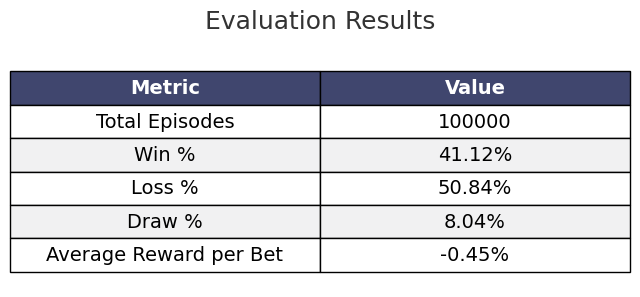

In [ ]:
# Assuming these variables are already computed from your evaluation:
# N_TEST_EPISODES, win_perc, loss_perc, draw_perc, avg_reward_eval

# Prepare table data
table_data = [
    ["Total Episodes", N_TEST_EPISODES],
    ["Win %", f"{win_perc:.2f}%"],
    ["Loss %", f"{loss_perc:.2f}%"],
    ["Draw %", f"{draw_perc:.2f}%"],
    ["Average Reward per Bet", f"{avg_reward_eval:.2f}%"]
]

# Create a figure and a single subplot
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('off')  # Turn off the axis

# Create the table and customize it
table = ax.table(cellText=table_data, colLabels=["Metric", "Value"],
                 cellLoc='center', loc='center')

# Adjust table style
table.auto_set_font_size(False)
table.set_fontsize(14)
table.scale(1, 2)

# Color the header and rows for a beautiful look
for (row, col), cell in table.get_celld().items():
    if row == 0:  # Header row
        cell.set_facecolor("#40466e")
        cell.set_text_props(color="w", weight="bold")
    else:
        # Alternate row colors for a more colorful effect
        if row % 2 == 0:
            cell.set_facecolor("#f1f1f2")
        else:
            cell.set_facecolor("#ffffff")

# Set a title with custom styling
plt.title("Evaluation Results", fontsize=18, color="#333333", pad=20)

# Save the figure as an image file in the 'results' folder
plt.savefig("results/evaluation_results.png", bbox_inches="tight", dpi=300)
plt.show()
